In [1]:
%load_ext autoreload
%autoreload 2

from pydantic import BaseModel, Field, create_model
from beartype import beartype

import numpy as np
import yaml

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score

import optuna
import mne

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import sys
from pathlib import Path

# Находим корень проекта (поднимаемся на уровень выше папки notebooks)
root = Path.cwd().parent
sys.path.append(str(root))

from utils.TFRDataset import TFRDataset

from utils.normalisation import normalize_tfr_robust
from utils.AlexNet import AlexNetTFR
from lib.optuna_objective_makers import *
from utils.optuna_constraints import slope_constraint

from collections import Counter

from optuna.trial import TrialState
from utils.optuna_study_analyzers import pareto_front, feasible_trials_less_zero
import gc

from utils.train_eval_helpers import train_one_epoch, eval_one_epoch_f1_macro

import warnings

In [2]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, timesteps, dropout):
        super(PositionalEncoding, self).__init__()
        self.dropout = torch.nn.Dropout(p=dropout)

        position = torch.arange(0, timesteps, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(timesteps, d_model)
        pe[:, 0::2] = 1*torch.sin(position * div_term)
        pe[:, 1::2] = 1*torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Transformer(torch.nn.Module):
    def __init__(self, seq_len, embed_dim, nhead, dim_fc, num_layers, dropout, device = device):
        super(Transformer, self).__init__()
        self.embed_layer = nn.LazyLinear(embed_dim)
        self.position_encoder = PositionalEncoding(d_model=embed_dim, timesteps=seq_len, dropout=dropout)
        encoder_layer = torch.nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                                         dim_feedforward=dim_fc, dropout=dropout, batch_first=True)
        self.encoder = torch.nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm_before_PE = torch.nn.LayerNorm(embed_dim)
        self.norm_after_PE = torch.nn.LayerNorm(embed_dim)
        self.fc1 = torch.nn.Linear(embed_dim, embed_dim)
        self.fc2 = torch.nn.Linear(embed_dim, embed_dim)
        # self.fc11 = torch.nn.Linear(embed_dim, embed_dim)
        # self.fc22 = torch.nn.Linear(embed_dim, embed_dim)
        self.fc3 = torch.nn.Linear(embed_dim, embed_dim)
        self.fc4 = torch.nn.Linear(embed_dim, embed_dim // 2)
        self.fc5 = torch.nn.Linear(embed_dim // 2, embed_dim // 4)
        self.fc6 = torch.nn.Linear(embed_dim // 4, 2)
        self.dropout = torch.nn.Dropout(dropout)
        self.activation = torch.nn.GELU()
        self.norm1 = torch.nn.LayerNorm(embed_dim)
        self.norm2 = torch.nn.LayerNorm(embed_dim)
        # self.norm11 = torch.nn.LayerNorm(embed_dim)
        # self.norm22 = torch.nn.LayerNorm(embed_dim)
        self.norm_conv = torch.nn.LayerNorm(embed_dim)
        # self.norm3 = torch.nn.LayerNorm(2)
        self.conv_layers = torch.nn.Sequential(
            # First Conv1d: input channels = embed_dim, output channels = embed_dim
            torch.nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(embed_dim),  # BatchNorm on channel dimension
            torch.nn.ReLU(),
            # torch.nn.BatchNorm1d(embed_dim),
            
            # Second Conv1d: maintaining embed_dim channels
            # torch.nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1),
            # torch.nn.BatchNorm1d(embed_dim),
            # torch.nn.ReLU(),
        )
    
        
    def forward(self, x):
        out = self.embed_layer(x)
        out = self.norm_before_PE(out)
        out = self.position_encoder(out)
        # residue = out
        # out = self.norm_before_PE(out)
        out = self.encoder(out)
        out = self.norm_after_PE(out)
        
#         out_conv = out.transpose(1, 2)  # -> [batch_size, embed_dim, seq_len]
#         out_conv = self.conv_layers(out_conv)  # -> [batch_size, embed_dim, seq_len]
#         out_conv = out_conv.transpose(1, 2) 
        
#         out = self.norm_conv(out_conv)#+out
        
        # out = self.norm_after_PE(out)
        residue = out
        out = self.dropout((self.activation(self.fc1(out))))
        
        out = self.norm1(out+residue)
        
        residue = out
        out = self.dropout((self.activation(self.fc2(out))))
        
        out = self.norm2(out+residue)
        
        out = self.dropout((self.activation(self.fc3(out))))
        # # out = out+residue
        out = self.dropout((self.activation(self.fc4(out))))
        out = self.dropout((self.activation(self.fc5(out))))
        out = (self.fc6(out))
        return out

In [3]:
# =========================================================
# 1. pooling по времени
# =========================================================

class SeqPool(nn.Module):

    def __init__(self, mode="mean"):
        super().__init__()
        assert mode in ["mean", "max", "last", "softmax", "none"], f"Unknown mode {mode}"
        self.mode = mode
        if self.mode == "softmax":
            self.score = nn.LazyLinear(1)

    def forward(self, x):
        # x: [B,T,D]

        if self.mode == "mean":
            return x.mean(dim=1)

        if self.mode == "max":
            return x.max(dim=1).values

        if self.mode == "last":
            return x[:, -1]

        if self.mode == "softmax":
            # x: [B,T,D]
            w = self.score(x)        # [B,T,1]
            w = torch.softmax(w, dim=1)
            return (x * w).sum(dim=1)   # [B,D]
        
        if self.mode == "none":
            return x

In [4]:
# =========================================================
# 2. бейзлайн reshape
# =========================================================

class TFRToSeqFlatten(nn.Module):
    """
    [B, C, F, T] -> [B, T, C*F]
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 4:
            raise ValueError(f"Expected [B,C,F,T], got {tuple(x.shape)}")

        B, C, Freq, Time = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()   # [B,T,C,F]
        x = x.reshape(B, Time, C * Freq)         # [B,T,C*F]
        return x


# =========================================================
# 3. вариант A: свёртка по каналам
#    один вес на один канал
#    [B,C,Freq,T] -> [B,T,Feat]
# =========================================================

class TFRToSeqChannelConvCollapse(nn.Module):
    """
    Свёртка в домене каналов:
    - один вес на один канал
    - схлопывание вдоль каналов
    - частоты остаются фичами
    - время остаётся sequence

    Реализация через conv3d с kernel = [C,1,1].
    """
    def __init__(self, bias: bool = True):
        super().__init__()
        self.bias_enabled = bias

        self._built = False
        self._channels = None

        self.channel_kernel = None
        self.channel_bias = None

    def _build(self, channels: int, device, dtype):
        self._channels = channels

        self.channel_kernel = nn.Parameter(
            torch.empty(channels, device=device, dtype=dtype)
        )
        nn.init.kaiming_uniform_(self.channel_kernel.view(1, 1, channels), a=math.sqrt(5))

        if self.bias_enabled:
            self.channel_bias = nn.Parameter(
                torch.zeros(1, device=device, dtype=dtype)
            )
        else:
            self.register_parameter("channel_bias", None)

        self._built = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 4:
            raise ValueError(f"Expected [B,C,F,T], got {tuple(x.shape)}")

        B, C, Freq, Time = x.shape

        if not self._built:
            self._build(C, x.device, x.dtype)

        if C != self._channels:
            raise ValueError(
                f"Channel count changed inside one model instance: expected C={self._channels}, got C={C}"
            )

        # [B,C,F,T] -> [B,1,C,F,T]
        x5 = x.unsqueeze(1)

        # kernel: [out_ch=1, in_ch=1, kC=C, kF=1, kT=1]
        kernel = self.channel_kernel.view(1, 1, C, 1, 1)

        out = F.conv3d(
            x5,
            weight=kernel,
            bias=self.channel_bias,
            stride=1,
            padding=0,
        )  # [B,1,1,F,T]

        out = out.squeeze(1).squeeze(1)          # [B,F,T]
        out = out.permute(0, 2, 1).contiguous()  # [B,T,F]
        return out


# =========================================================
# 4. вариант B: свёртка в домене F×T
#    один и тот же FT-kernel на все каналы
#    и этим же kernel'ом каналы схлопываются
#    [B,C,F,T] -> [B,T,F]
# =========================================================

class TFRToSeqFTPlaneConvCollapse(nn.Module):
    """
    Свёртка в домене частота×время:
    - обучаемый kernel [kF, kT]
    - один и тот же kernel повторяется на все каналы
    - каналы схлопываются внутри conv3d
    - output: [B,T,F]

    Важный смысл:
    weights живут в плоскости F×T, а не в канальной оси.
    """

    def __init__(self, kernel_freq: int = 3, kernel_time: int = 3, bias: bool = True):
        super().__init__()

        if kernel_freq <= 0 or kernel_time <= 0:
            raise ValueError("kernel_freq and kernel_time must be > 0")

        self.kernel_freq = kernel_freq
        self.kernel_time = kernel_time
        self.bias_enabled = bias

        self._built = False
        self._channels = None

        self.ft_kernel = None
        self.ft_bias = None

    def _build(self, channels: int, device, dtype):
        self._channels = channels

        self.ft_kernel = nn.Parameter(
            torch.empty(self.kernel_freq, self.kernel_time, device=device, dtype=dtype)
        )
        nn.init.kaiming_uniform_(
            self.ft_kernel.view(1, 1, self.kernel_freq, self.kernel_time),
            a=math.sqrt(5)
        )

        if self.bias_enabled:
            self.ft_bias = nn.Parameter(
                torch.zeros(1, device=device, dtype=dtype)
            )
        else:
            self.register_parameter("ft_bias", None)

        self._built = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 4:
            raise ValueError(f"Expected [B,C,F,T], got {tuple(x.shape)}")

        B, C, Freq, Time = x.shape

        if not self._built:
            self._build(C, x.device, x.dtype)

        if C != self._channels:
            raise ValueError(
                f"Channel count changed inside one model instance: expected C={self._channels}, got C={C}"
            )

        # [B,C,F,T] -> [B,1,C,F,T]
        x5 = x.unsqueeze(1)

        # один и тот же FT-kernel повторяем на все каналы
        # kernel: [1,1,C,kF,kT]
        kernel = self.ft_kernel.view(1, 1, 1, self.kernel_freq, self.kernel_time)
        kernel = kernel.repeat(1, 1, C, 1, 1)

        pad_f = self.kernel_freq // 2
        pad_t = self.kernel_time // 2

        out = F.conv3d(
            x5,
            weight=kernel,
            bias=self.ft_bias,
            stride=1,
            padding=(0, pad_f, pad_t),
        )  # [B,1,1,F,T] при kF,kT нечетных

        out = out.squeeze(1).squeeze(1)          # [B,F,T]
        out = out.permute(0, 2, 1).contiguous()  # [B,T,F]
        return out


class TFRToSeqPixelWeightCollapse(nn.Module):
    """
    Каждый пиксель (f,t) имеет свой обучаемый вес.

    x: [B, C, F, T]
    w: [F, T]

    y[f,t] = w[f,t] * sum_c x[c,f,t]

    output: [B, T, F]
    """

    def __init__(self):
        super().__init__()
        self.weight = None
        self._built = False
        self._shape = None

    def _build(self, F, T, device, dtype):
        self.weight = nn.Parameter(
            torch.randn(F, T, device=device, dtype=dtype)
        )
        self._shape = (F, T)
        self._built = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        if x.ndim != 4:
            raise ValueError(f"Expected [B,C,F,T], got {tuple(x.shape)}")

        B, C, F, T = x.shape

        if not self._built:
            self._build(F, T, x.device, x.dtype)

        if (F, T) != self._shape:
            raise ValueError(
                f"(F,T) changed inside one model instance: expected {self._shape}, got {(F,T)}"
            )

        # collapse channels
        x = x.sum(dim=1)          # [B, F, T]

        # pixel weighting
        x = x * self.weight       # [B, F, T]

        # transformer layout
        x = x.permute(0, 2, 1)    # [B, T, F]

        return x

In [5]:
# =========================================================
# 7. главная обёртка
# =========================================================

class TFRTransformerWrapper(nn.Module):
    """
    Вход:  [B, C, F, T]
    Выход: [B, num_classes]

    preprocess:
      - "flatten"
      - "channel_conv"
      - "ft_plane_conv"
    """
    def __init__(
        self,
        num_classes: int = 2,
        dropout: float = 0.5,
        *,
        seq_len: int = 1001,
        pooling: str = SeqPool(mode = "softmax"),
        preprocess: str = TFRToSeqFlatten(),
        kernel_freq: int = 3,
        kernel_time: int = 3,
        embed_dim: int = 256,
        nhead: int = 8,
        dim_fc: int = 512,
        num_layers: int = 4,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.pooling = pooling
        self.preprocess = preprocess
        self.transformer = Transformer(
            seq_len=seq_len,
            embed_dim=embed_dim, 
            nhead=nhead, 
            dim_fc=dim_fc, 
            num_layers=num_layers,
            dropout=dropout
        )

        self.token_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        [B,C,F,T] -> [B,num_classes]
        """
        preprocess = self.preprocess(x)
        feat = self.transformer(preprocess)
        pooled = self.pooling(feat)
        # logits = self.token_head(pooled)
        return pooled

In [6]:
with open('../patients.yaml') as f:
    test = yaml.safe_load(f)

In [7]:
pat_config = test['default']

In [8]:
# time_frequency_file = pat_config['time_frequency_file'] 
time_frequency_file = "../specs_with_car/tfr_s11.fif"
min_f, max_f, min_t, max_t = pat_config['min_f'], pat_config['max_f'], pat_config['min_t'], pat_config['max_t']

tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]

Reading ../specs_with_car/tfr_s11.fif ...


/tmp/ipykernel_1690384/1871218919.py:5: RuntimeWarning: This filename (../specs_with_car/tfr_s11.fif) does not conform to MNE naming conventions. All tfr files should end with -tfr.h5 or _tfr.h5
  tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]


Not setting metadata


In [9]:
y = np.where(tfr.events[:, 2] == 9, 1, 0)

In [10]:
# X = normalize_tfr_robust(tfr.crop(tmin=0.0, tmax=1.0).data)[:, :, min_f:max_f, min_t:max_t]
X = normalize_tfr_robust(tfr.crop(tmin=0.0, tmax=1.0).data)[:, :, :-50, :]
del tfr
gc.collect() # Теперь память гарантировано свободна

20

In [11]:
# if preprocess == "flatten":
#     preprocess = TFRToSeqFlatten()

# elif preprocess == "channel_conv":
#     preprocess = TFRToSeqChannelConvCollapse()

# elif preprocess == "ft_plane_conv":
#     preprocess = TFRToSeqFTPlaneConvCollapse(
#         kernel_freq=kernel_freq,
#         kernel_time=kernel_time,
#     )

# elif preprocess == "":
#     preprocess = TFRToSeqPixelWeightCollapse(
#         freq_bins=40, 
#         seq_len=100
#     )

# else:
#     raise ValueError(
#         f"Unknown preprocess={preprocess!r}. "
#         f"Use 'flatten', 'channel_conv', or 'ft_plane_conv'."
#     )

In [12]:
@beartype
def params_fn_factory(
    *,
    num_classes: int,
    ) -> Callable[[Any], Params]:
    PREPROCESS_MAP = {
        "flatten": TFRToSeqFlatten,
        "channel_conv": TFRToSeqChannelConvCollapse,
        "ft_plane_conv": TFRToSeqFTPlaneConvCollapse,
        "pixel_weight": TFRToSeqPixelWeightCollapse,
    }    
    def _params_fn(trial) -> Params:
        params_dict = {}

        embed_dim = trial.suggest_categorical("embed_dim", [32, 64, 128, 256])
        possible_heads = [h for h in [1, 2, 4, 8] if embed_dim % h == 0]

        params_dict["model"] = {
            "num_classes": num_classes,
            "embed_dim": embed_dim,
            "nhead": trial.suggest_categorical("nhead", possible_heads),
            "dim_fc": trial.suggest_categorical("dim_fc", [64, 128, 256, 512]),
            "num_layers": trial.suggest_int("num_layers", 1, 4),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "pooling": SeqPool(mode=trial.suggest_categorical("pooling", ["mean", "softmax"])),
            "preprocess": PREPROCESS_MAP[trial.suggest_categorical("preprocess", ["flatten", "channel_conv", "ft_plane_conv", "pixel_weight"])](),
        }
        params_dict["optimizer"] = {
                "lr": trial.suggest_float("lr", 1e-5, 3e-3, log=True),
                "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            }
        params_dict["tr_dataset"] = {
                "time_crop": None,
                # в будущем:
                # зависимые:
                # "time_crop": (
                #     trial.suggest_int("time_crop", 200, 278)  # или T из ctx, если добавишь ctx
                #     if trial.suggest_categorical("time_crop_on", [0, 1]) else None
                # ),
            }
        params_dict["tr_loader"] = {
                # "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
                "batch_size": trial.suggest_categorical("batch_size", [64]),
                "shuffle": True
                # можно добавить:
                # "num_workers": 4,
                # "pin_memory": True,
            }
        params_dict["vl_dataset"] = dict(params_dict["tr_dataset"])
        params_dict["vl_loader"] = dict(params_dict["tr_loader"])
        params_dict["vl_loader"]["shuffle"] = False
        return params_dict
    return _params_fn

In [13]:
cv=True
max_epochs = 100
num_classes = 2
channels = X.shape[1]
seed = 42
test_size = 0.2
n_trials_optuna_whole = 100
n_startup_trials, n_warmup_steps = 5, 5
patience=6
constraints_func = slope_constraint
cv_aggregate = "median"
sampler = optuna.samplers.NSGAIISampler(
    seed=seed,
    constraints_func=constraints_func,   # <-- сюда
)

study = optuna.create_study(
    # макс метрику качества, мин метрику ошибки
    directions=["maximize", "minimize"],
    # sampler=optuna.samplers.TPESampler(), для сингл обджектива
    sampler=sampler
    # pruner=optuna.pruners.MedianPruner(n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps) # может вызвать ошибки, так как прунер настроен на одиночную метрику
)

/trinity/home/t.samsonov/miniconda3/envs/brainbert/lib/python3.10/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-03-17 11:54:43,480] A new study created in memory with name: no-name-c9d86a30-b624-41f1-bb67-1792c53f65b7


In [14]:
objective = make_objective_engine(
    X=X, y=y,
    make_splits_fn=make_splits_fn_factory(test_size=test_size, seed=seed, cv=cv),
    run_fold_fn=run_fold_fn_factory(
        ModelCls=TFRTransformerWrapper, device=device, 
        max_epochs=max_epochs, patience=patience,
        TFRDataset=TFRDataset, DataLoader=DataLoader,
        train_one_epoch=train_one_epoch, eval_one_epoch_f1_macro=eval_one_epoch_f1_macro,
        loss_metric=loss_slope
    ),
    aggregate_mode=cv_aggregate,
    params_fn=params_fn_factory(
        num_classes=num_classes,
    ),
    objectives_fn=objectives_fn,
    attrs_fn=attrs_fn,
)


In [15]:
warnings.simplefilter("ignore")
study.optimize(objective, n_trials=n_trials_optuna_whole, show_progress_bar=True)

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-17 11:55:01,200] Trial 0 finished with values: [0.3333333333333333, -0.0028407296964100422] and parameters: {'embed_dim': 64, 'nhead': 8, 'dim_fc': 512, 'num_layers': 4, 'dropout': 0.18493564427131048, 'pooling': 'softmax', 'preprocess': 'channel_conv', 'lr': 0.0003278187653397617, 'weight_decay': 3.6138942712165278e-06, 'batch_size': 64}.
[I 2026-03-17 11:55:14,799] Trial 1 finished with values: [0.408130081300813, -0.00010263281209132058] and parameters: {'embed_dim': 256, 'nhead': 4, 'dim_fc': 512, 'num_layers': 4, 'dropout': 0.4233589392465845, 'pooling': 'mean', 'preprocess': 'flatten', 'lr': 1.216702881459345e-05, 'weight_decay': 0.004337920697490943, 'batch_size': 64}.
[I 2026-03-17 11:55:20,488] Trial 2 finished with values: [0.3333333333333333, -8.597331387657635e-05] and parameters: {'embed_dim': 64, 'nhead': 4, 'dim_fc': 64, 'num_layers': 1, 'dropout': 0.1783931449676581, 'pooling': 'softmax', 'preprocess': 'ft_plane_conv', 'lr': 4.9648810171066576e-05, 'weight_de

In [17]:
from utils.optuna_study_analyzers import pareto_front, feasible_trials_less_zero

In [16]:
cnt = Counter([t.state for t in study.trials])
print(cnt)
print(study.directions)

pareto = study.best_trials
print("Pareto trials:", len(pareto))

for t in pareto[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

Counter({<TrialState.COMPLETE: 1>: 100})
[<StudyDirection.MAXIMIZE: 2>, <StudyDirection.MINIMIZE: 1>]
Pareto trials: 3
trial=32 f1=0.6571 slope=-0.002463 params={'embed_dim': 64, 'nhead': 4, 'dim_fc': 512, 'num_layers': 4, 'dropout': 0.48601076426660506, 'pooling': 'softmax', 'preprocess': 'flatten', 'lr': 0.00026487413956088055, 'weight_decay': 0.002329781042267056, 'batch_size': 64}
trial=53 f1=0.6410 slope=-0.007463 params={'embed_dim': 64, 'nhead': 1, 'dim_fc': 512, 'num_layers': 3, 'dropout': 0.25887341184738194, 'pooling': 'mean', 'preprocess': 'channel_conv', 'lr': 0.002914119211112836, 'weight_decay': 9.793184984206256e-06, 'batch_size': 64}
trial=56 f1=0.7418 slope=-0.000826 params={'embed_dim': 32, 'nhead': 2, 'dim_fc': 512, 'num_layers': 2, 'dropout': 0.1440207698110707, 'pooling': 'softmax', 'preprocess': 'channel_conv', 'lr': 0.0014586805006902503, 'weight_decay': 7.7344821566468e-06, 'batch_size': 64}


In [18]:
feasible = feasible_trials_less_zero(study)

print("complete:", sum(t.state == TrialState.COMPLETE for t in study.trials))
print("feasible:", len(feasible))

pareto = pareto_front(feasible, study.directions)
print("Pareto feasible:", len(pareto))

for t in sorted(pareto, key=lambda x: x.values[0], reverse=True)[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

complete: 100
feasible: 88
Pareto feasible: 3
trial=56 f1=0.7418 slope=-0.000826 params={'embed_dim': 32, 'nhead': 2, 'dim_fc': 512, 'num_layers': 2, 'dropout': 0.1440207698110707, 'pooling': 'softmax', 'preprocess': 'channel_conv', 'lr': 0.0014586805006902503, 'weight_decay': 7.7344821566468e-06, 'batch_size': 64}
trial=32 f1=0.6571 slope=-0.002463 params={'embed_dim': 64, 'nhead': 4, 'dim_fc': 512, 'num_layers': 4, 'dropout': 0.48601076426660506, 'pooling': 'softmax', 'preprocess': 'flatten', 'lr': 0.00026487413956088055, 'weight_decay': 0.002329781042267056, 'batch_size': 64}
trial=53 f1=0.6410 slope=-0.007463 params={'embed_dim': 64, 'nhead': 1, 'dim_fc': 512, 'num_layers': 3, 'dropout': 0.25887341184738194, 'pooling': 'mean', 'preprocess': 'channel_conv', 'lr': 0.002914119211112836, 'weight_decay': 9.793184984206256e-06, 'batch_size': 64}


Trial number: 56
Values (f1, slope): [0.7417654808959157, -0.0008257862293359364]
Params: {'embed_dim': 32, 'nhead': 2, 'dim_fc': 512, 'num_layers': 2, 'dropout': 0.1440207698110707, 'pooling': 'softmax', 'preprocess': 'channel_conv', 'lr': 0.0014586805006902503, 'weight_decay': 7.7344821566468e-06, 'batch_size': 64}


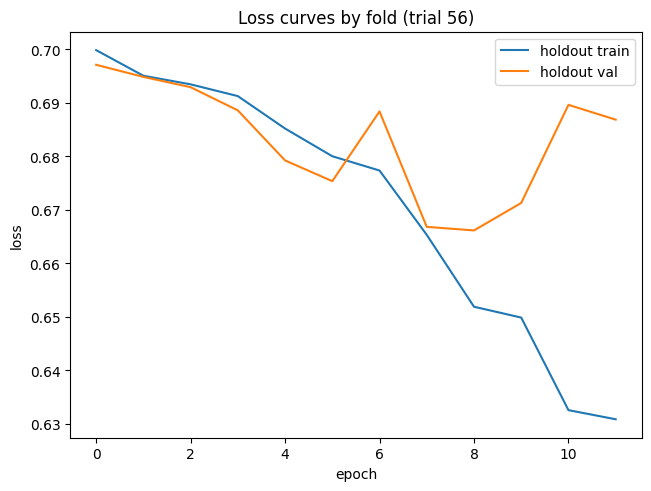

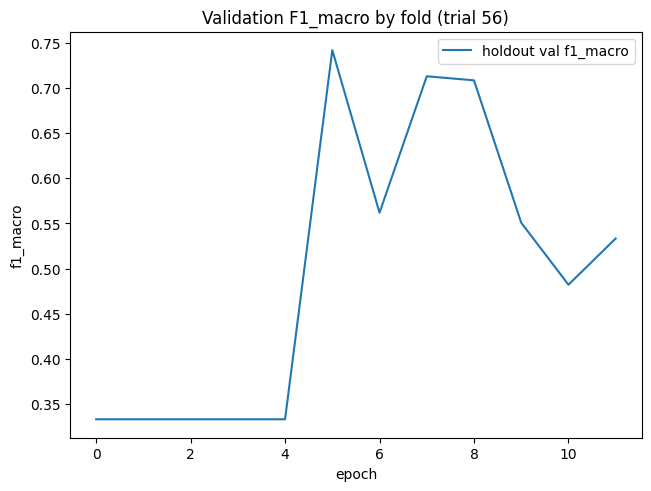

Trial number: 32
Values (f1, slope): [0.6571428571428571, -0.0024631724213108725]
Params: {'embed_dim': 64, 'nhead': 4, 'dim_fc': 512, 'num_layers': 4, 'dropout': 0.48601076426660506, 'pooling': 'softmax', 'preprocess': 'flatten', 'lr': 0.00026487413956088055, 'weight_decay': 0.002329781042267056, 'batch_size': 64}


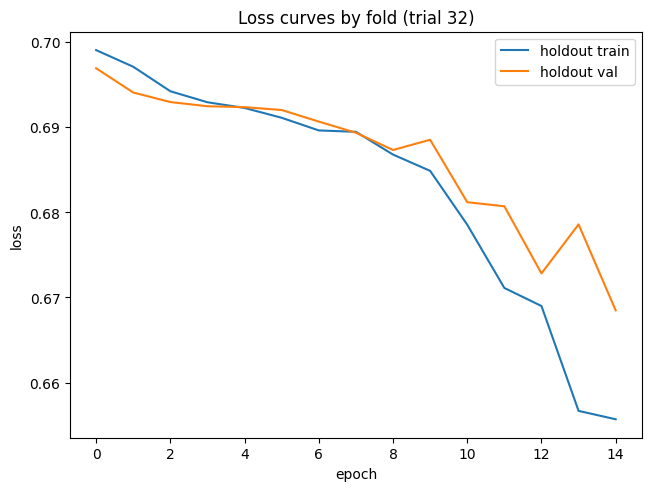

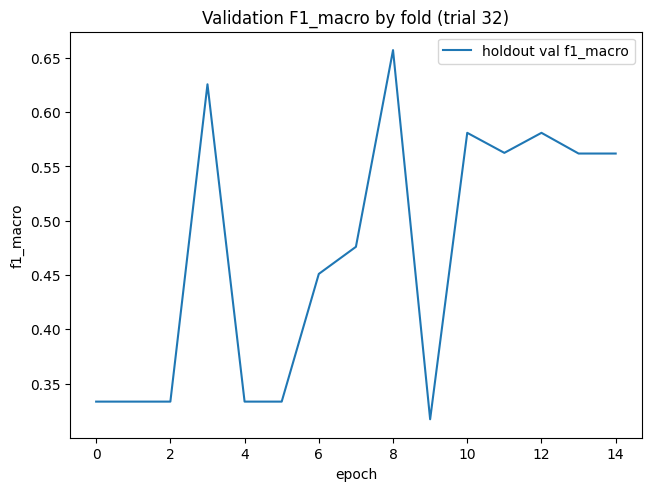

Trial number: 53
Values (f1, slope): [0.641025641025641, -0.007462919480872888]
Params: {'embed_dim': 64, 'nhead': 1, 'dim_fc': 512, 'num_layers': 3, 'dropout': 0.25887341184738194, 'pooling': 'mean', 'preprocess': 'channel_conv', 'lr': 0.002914119211112836, 'weight_decay': 9.793184984206256e-06, 'batch_size': 64}


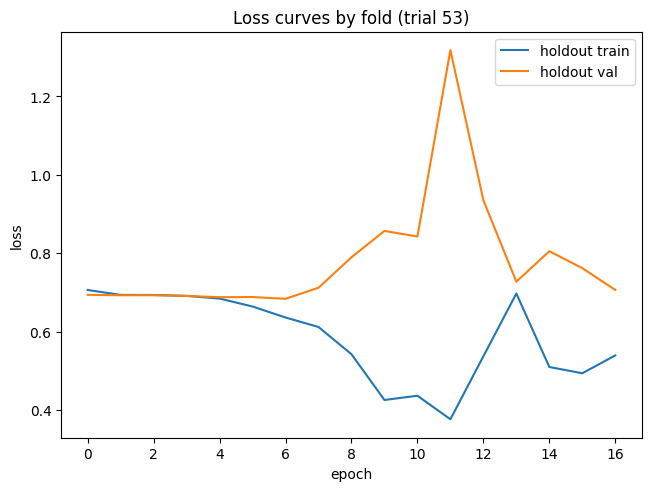

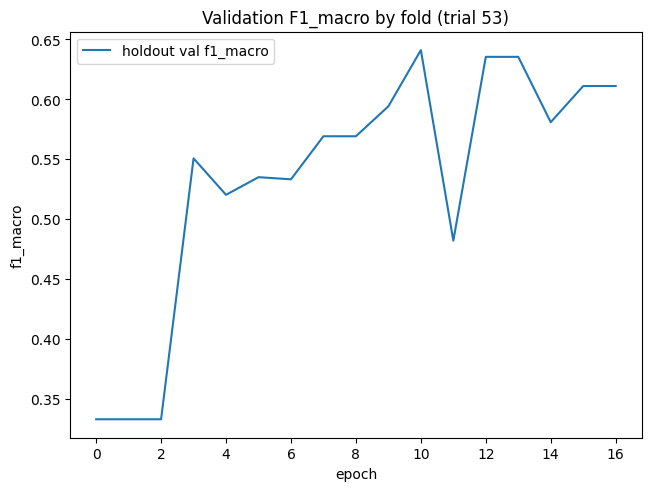

In [23]:
import matplotlib.pyplot as plt

# --- выбери trial по номеру (надёжнее, чем индекс в списке) ---
trial_number = [56, 32, 53]
for t in trial_number:
    t = study.get_trials(deepcopy=False)[t]  # если номера идут подряд, ок
    # более надёжно, если есть пропуски:
    # t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

    print("Trial number:", t.number)
    print("Values (f1, slope):", t.values)
    print("Params:", t.params)

    # --- новая номенклатура: fold_curves ---
    fold_curves = t.user_attrs.get("fold_curves", None)

    if fold_curves is not None and len(fold_curves) > 0:
        # 1) Loss curves по фолдам
        plt.figure(constrained_layout=True)
        for fc in fold_curves:
            name = fc.get("split", "fold")
            tr_losses = fc.get("train_losses", [])
            va_losses = fc.get("val_losses", [])
            if tr_losses:
                plt.plot(tr_losses, label=f"{name} train")
            if va_losses:
                plt.plot(va_losses, label=f"{name} val")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title(f"Loss curves by fold (trial {t.number})")
        plt.legend()
        plt.show()

        # 2) F1 curves по фолдам
        plt.figure(constrained_layout=True)
        for fc in fold_curves:
            name = fc.get("split", "fold")
            va_f1s = fc.get("val_f1s", [])
            if va_f1s:
                plt.plot(va_f1s, label=f"{name} val f1_macro")
        plt.xlabel("epoch")
        plt.ylabel("f1_macro")
        plt.title(f"Validation F1_macro by fold (trial {t.number})")
        plt.legend()
        plt.show()

    else:
        # --- fallback: старая номенклатура ---
        train_losses = t.user_attrs.get("train_losses", [])
        val_losses   = t.user_attrs.get("val_losses", [])
        val_f1s      = t.user_attrs.get("val_f1s", [])

        plt.figure(constrained_layout=True)
        if train_losses:
            plt.plot(train_losses, label="train loss")
        if val_losses:
            plt.plot(val_losses, label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title(f"Loss curves (trial {t.number})")
        plt.legend()
        plt.show()

        plt.figure(constrained_layout=True)
        if val_f1s:
            plt.plot(val_f1s, label="val f1_macro")
        plt.xlabel("epoch")
        plt.ylabel("f1_macro")
        plt.title(f"Validation F1_macro (trial {t.number})")
        plt.legend()
        plt.show()